# 1. 데이터 로드 및 병합
- 7개의 원본 CSV를 로드하고 하나의 Master DataFrame으로 병합합니다.

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

def load_and_merge():
    files = {
        '기본정보': '기본정보.csv', '면적정보': '면적정보.csv', '시설정보': '시설정보.csv',
        '운영정보': '운영정보.csv', '위치정보': '위치정보.csv', '장기수선': '장기수선.csv', '관리비': '관리비.csv'
    }
    dfs = {}
    for name, filename in files.items():
        path = os.path.join(DATA_DIR, filename)
        try:
            dfs[name] = pd.read_csv(path, encoding='utf-8')
        except UnicodeDecodeError:
            dfs[name] = pd.read_csv(path, encoding='cp949')

    if '면적정보' in dfs:
        dfs['면적정보'] = dfs['면적정보'].drop_duplicates(subset=['단지코드']).drop(columns=['주거전용면적(세부)', '세대수'], errors='ignore')

    static_df = dfs['기본정보']
    for table_name in ['면적정보', '시설정보', '운영정보', '위치정보']:
        df_to_merge = dfs[table_name]
        cols_to_use = [col for col in df_to_merge.columns if col not in static_df.columns or col == '단지코드']
        static_df = pd.merge(static_df, df_to_merge[cols_to_use], on='단지코드', how='left')
    
    ts_df = dfs['관리비']
    repair_df = dfs['장기수선']
    join_keys = ['단지코드', '발생년월(YYYYMM)']
    cols_to_use = [col for col in repair_df.columns if col not in ts_df.columns or col in join_keys]
    ts_df = pd.merge(ts_df, repair_df[cols_to_use], on=join_keys, how='left')
    
    raw_master_df = pd.merge(ts_df, static_df, on='단지코드', how='left')
    return raw_master_df

raw_master_df = load_and_merge()
print(f"병합 완료된 원본 데이터 크기: {raw_master_df.shape}")
raw_master_df.head()

병합 완료된 원본 데이터 크기: (147240, 87)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 1-1. 세대수 데이터 보정

`기본정보.csv`의 `세대수`와 `면적정보.csv`(평형별 세대수의 단지 합계)가 서로 다른 단지를 전수 조사한 결과 **83개 단지**에서 불일치가 확인됐습니다(양방향 모두 존재 — 기본정보가 더 작은 경우와 더 큰 경우가 섞여 있음).

외부 참조자료(`서울시 공동주택 아파트 정보(위도경도 포함)` CSV, 아파트 단지별 상세 정보를 담은 공개 자료의 `k-전체세대수` 컬럼, 2454개 단지 전부 매칭됨)로 교차 검증해, **79개 단지**는 참조자료 값으로 `세대수`를 보정합니다. 나머지 4개 단지(`A13528105`, `A10027289`, `A13527017`, `A13402304`)는 참조자료 값이 0/결측이라 보정하지 않고 원본을 유지합니다(추후 별도 확인 필요).

In [2]:
# 세대수 보정 매핑: 단지코드 -> 정확한 세대수
# 출처: 서울시 공동주택 아파트 정보(위도경도 포함) 참조자료의 `k-전체세대수` 컬럼
# 기본정보.csv 세대수와 면적정보.csv 세대수 합계가 불일치한 83개 단지 중,
# 참조자료 값이 유효한(0/결측이 아닌) 79개 단지만 포함
HOUSEHOLD_COUNT_CORRECTIONS = {
    'A10023788': 276, 'A10023815': 249, 'A10024408': 306, 'A10024891': 913,
    'A10025013': 959, 'A10026004': 607, 'A10026036': 927, 'A10026710': 208,
    'A10026748': 1976, 'A10027851': 940, 'A10028042': 245, 'A10028172': 716,
    'A10028201': 182, 'A10045302': 3118, 'A10086301': 286, 'A10095501': 297,
    'A12009304': 554, 'A12009305': 768, 'A12201102': 300, 'A12275501': 254,
    'A13003406': 741, 'A13009002': 1224, 'A13009206': 445, 'A13070101': 190,
    'A13186305': 858, 'A13188406': 345, 'A13203408': 690, 'A13276417': 489,
    'A13307002': 457, 'A13475001': 191, 'A13484003': 277, 'A13522006': 1163,
    'A13522008': 2565, 'A13528004': 2436, 'A13528005': 372, 'A13552001': 1513,
    'A13572601': 239, 'A13582002': 548, 'A13590204': 826, 'A13593908': 1623,
    'A13607302': 354, 'A13615002': 453, 'A13679902': 201, 'A13703011': 256,
    'A13707006': 293, 'A13792001': 2390, 'A13812004': 249, 'A13812005': 889,
    'A13822902': 555, 'A13872503': 523, 'A13879102': 3930, 'A13880406': 839,
    'A13881204': 672, 'A13977913': 2634, 'A14070302': 589, 'A14085002': 554,
    'A14086001': 578, 'A14319012': 1177, 'A15003001': 271, 'A15005402': 826,
    'A15007002': 233, 'A15089421': 1584, 'A15101101': 688, 'A15101507': 960,
    'A15183001': 387, 'A15210105': 252, 'A15303103': 233, 'A15383308': 1226,
    'A15383702': 786, 'A15383905': 640, 'A15703313': 1670, 'A15722010': 442,
    'A15776715': 1146, 'A15780705': 1998, 'A15780806': 2412, 'A15785612': 1000,
    'A15805503': 1382, 'A15882104': 183, 'A41279927': 335,
}

def correct_household_counts(df, correction_map=HOUSEHOLD_COUNT_CORRECTIONS):
    df = df.copy()
    corrected = df['단지코드'].map(correction_map)
    n_complexes = df.loc[corrected.notna(), '단지코드'].nunique()
    df['세대수'] = corrected.fillna(df['세대수'])
    print(f"세대수 보정 적용: {n_complexes}개 단지")
    return df

raw_master_df = correct_household_counts(raw_master_df)
raw_master_df[raw_master_df['단지코드'].isin(HOUSEHOLD_COUNT_CORRECTIONS)][['단지코드', '세대수']].drop_duplicates('단지코드').head()

세대수 보정 적용: 79개 단지


,단지코드,세대수
324,A10086301,286.0
348,A10028201,182.0
432,A10045302,3118.0
540,A10095501,297.0
624,A10023788,276.0


# 2. 데이터 전처리
- 2-1. 결측치 처리
- 2-2. 칼럼 삭제
- 2-3. 파생변수 생성
- 2-4. 다중공선성 확인 (VIF)

## 2-1. 결측치 처리
- `경비관리-인원`(0.49%, 12개 단지) 결측치를 **세대수 사분위 구간 × 관리방식 그룹 중앙값**으로 대치합니다.
- 그 외 관리비/시설 항목의 0값들(난방비, 임대세대수 등)은 결측이 아니라 정당한 값(구조적 0·이벤트성 0)으로 판단되어 별도 처리하지 않습니다.
- 근거 및 검증 과정: `문서/작업과정/결측치_처리_점검_20260826.md`

In [3]:
def handle_missing_values(df):
    df = df.copy()
    missing_codes = df.loc[df['경비관리-인원'].isna(), '단지코드'].unique()

    complexes = df.drop_duplicates('단지코드').copy()
    q1, q2, q3 = complexes['세대수'].quantile([.25, .5, .75])

    def bucket_size(x):
        if x <= q1:
            return '소형'
        if x <= q2:
            return '중소형'
        if x <= q3:
            return '중대형'
        return '대형'

    complexes['세대수구간'] = complexes['세대수'].apply(bucket_size)
    df = df.merge(complexes[['단지코드', '세대수구간']], on='단지코드', how='left')

    group_median = (
        df.dropna(subset=['경비관리-인원'])
        .groupby(['세대수구간', '관리방식'])['경비관리-인원']
        .median()
    )

    def impute_guard_staff(row):
        if pd.notna(row['경비관리-인원']):
            return row['경비관리-인원']
        key = (row['세대수구간'], row['관리방식'])
        if key in group_median.index:
            return group_median.loc[key]
        return group_median.loc[row['세대수구간']].median()  # fallback: 관리방식 무시하고 세대수구간 전체 중앙값

    df['경비관리-인원'] = df.apply(impute_guard_staff, axis=1)
    df = df.drop(columns=['세대수구간'])

    print(f"결측치 대치 완료: {len(missing_codes)}개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치")
    print(f"대치 후 남은 결측 수: {df['경비관리-인원'].isna().sum()}")
    return df

raw_master_df = handle_missing_values(raw_master_df)
raw_master_df.head()

결측치 대치 완료: 12개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치
대치 후 남은 결측 수: 0


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 2-2. 칼럼 삭제
- 병합된 데이터프레임에서 불필요한 칼럼을 삭제합니다.
- `장충금 적립률`은 2026-08-26 팀 결정으로 삭제 목록에 추가했습니다 (0값 비율의 원인을 설명할 수 없어 삭제 — 근거는 위 결측치 처리 점검 문서 참고).

In [4]:
def preprocess_data(df):
    cols_to_drop = [
        '차량유지비', '지능형네트워크유지비', '재해예방비', '가스사용료(공용)', '가스사용료(전용)', '기타', '제세공과금', '교육훈련비', '시설유지비', '안전점검비', '위탁관리수수료', '급탕비(공용)', '수도료(공용)', 'TV수신료', '정화조오물수수료', '선관위운영비',
        '시공사', '주택관리업자',
        '건물구조', '전기-수전용량', '전기-세대전기계약방식', '승강기관리-관리방식', 'CCTV대수', '부대복리시설', '홈네트워크',
        '경비관리-계약업체', '청소관리-계약업체', '음식물 처리방법', '소독관리-계약업체', '일반관리-관리방식', '경비관리-관리방식', '청소관리-관리방식', '소독관리-관리방식',
        '입주자기여수익', '공동기여수익',
        '장충금 적립률',  # 2026-08-26 팀 결정: 0비율 원인 설명 불가로 삭제
    ]
    existing_cols = [col for col in cols_to_drop if col in df.columns]
    df_cleaned = df.drop(columns=existing_cols)
    
    print(f"삭제된 칼럼 수: {len(existing_cols)}개")
    print(f"전처리 완료 후 최종 남은 데이터 크기: {df_cleaned.shape}")
    return df_cleaned

final_df = preprocess_data(raw_master_df)
final_df.head()

삭제된 칼럼 수: 34개
전처리 완료 후 최종 남은 데이터 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,피복비,그밖의부대비용,청소비,경비비,소독비,...,주거전용면적(단지합계),승강기대수,총주차대수,최고층수,지하층수,일반관리-인원,경비관리-인원,청소관리-인원,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,0,341860,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,0,326160,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,0,711840,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,0,315660,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,0,398410,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151


## 2-3. 파생변수 생성
- 비용 항목 24개 + 시설·인원 5개(승강기대수, 총주차대수, 일반/경비/청소관리-인원)를 `관리비부과면적` 기준으로 정규화(`_perm2`)하여 `per_df`를 만듭니다.
- `동수`, `분양세대수`/`임대세대수`는 이번엔 파생변수를 만들지 않고 원값 그대로 둡니다.
- 상세 근거: [의사결정 로그](https://app.notion.com/p/3c9831afe087812ba44bfe9b8fad522e)

In [5]:
# 관리비부과면적당 단가로 환산할 금액(비용) 컬럼 목록
AMOUNT_COLS = [
    # 관리비.csv 유래
    '공용관리비계', '인건비', '제사무비', '피복비', '그밖의부대비용', '청소비', '경비비', '소독비',
    '승강기유지비', '수선비', '개별사용료계', '난방비(공용)', '난방비(전용)', '급탕비(전용)',
    '전기료(공용)', '전기료(전용)', '수도료(전용)', '생활폐기물수수료', '입대의운영비', '건물보험료',
    # 장기수선.csv 유래
    '장충금 월부과액', '장충금 월사용액', '장충금 총적립금액', '잡수입 월수입금액',
    # 시설·인원 수 (2026-08-27 팀 결정: 세대수 대신 관리비부과면적 기준으로 정규화. 동수는 제외)
    '승강기대수', '총주차대수', '일반관리-인원', '경비관리-인원', '청소관리-인원',
]

def calc_per_area(df, amount_cols=AMOUNT_COLS, area_col='관리비부과면적'):
    cols = [c for c in amount_cols if c in df.columns]
    df_perm2 = df.copy()
    df_perm2[cols] = df[cols].div(df[area_col], axis=0)
    df_perm2 = df_perm2.rename(columns={c: f'{c}_perm2' for c in cols})
    return df_perm2

per_df = calc_per_area(final_df)
print(f"per_df 크기: {per_df.shape}")
per_df.head()

per_df 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계_perm2,인건비_perm2,제사무비_perm2,피복비_perm2,그밖의부대비용_perm2,청소비_perm2,경비비_perm2,소독비_perm2,...,주거전용면적(단지합계),승강기대수_perm2,총주차대수_perm2,최고층수,지하층수,일반관리-인원_perm2,경비관리-인원_perm2,청소관리-인원_perm2,위도,경도
0,A11007001,202101,1389.459752,561.390304,6.472770,0.0,8.904552,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
1,A11007001,202102,1385.437387,561.388793,6.462351,0.0,8.495608,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
2,A11007001,202103,1386.470869,561.388845,5.951823,0.0,18.541556,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
3,A11007001,202104,1354.353739,533.591723,6.352952,0.0,8.222111,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
4,A11007001,202105,1364.475328,533.831880,6.019546,0.0,10.377531,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151


## per_df 정리 - 비아파트 단지 제외 후 `단지분류` 컬럼 삭제
- `단지분류`가 `주상복합`, `연립주택`, `도시형 생활주택(주상복합)`, `도시형 생활주택(아파트)`, `다세대`인 행을 모두 제거하고 `아파트`만 남긴다.
- 필터링이 끝나면 모든 행이 `아파트`로 동일해져 `단지분류` 컬럼이 더 이상 정보를 담지 않으므로 삭제한다.
- **이 필터링은 `per_df` 생성 직후, VIF·PCA·이후 분석 이전에 적용한다** — 그래야 뒤따르는 모든 분석이 아파트만 대상으로 한 결과가 된다.

In [6]:
NON_APT_TYPES = ['주상복합', '연립주택', '도시형 생활주택(주상복합)', '도시형 생활주택(아파트)', '다세대']

before_shape = per_df.shape
per_df = per_df[~per_df['단지분류'].isin(NON_APT_TYPES)].reset_index(drop=True)
print(f"비아파트 제외 전: {before_shape} -> 제외 후: {per_df.shape}")

per_df = per_df.drop(columns=['단지분류'])
print(f"'단지분류' 컬럼 삭제 후 per_df 크기: {per_df.shape}")
print(f"컬럼 수: {per_df.shape[1]}")
print(f"단지코드(고유 단지) 수: {per_df['단지코드'].nunique()}")

비아파트 제외 전: (147240, 53) -> 제외 후: (133380, 53)


'단지분류' 컬럼 삭제 후 per_df 크기: (133380, 52)
컬럼 수: 52
단지코드(고유 단지) 수: 2223


## 2-4. 다중공선성 확인 (VIF)

**VIF (Variance Inflation Factor)**
- 각 독립변수 하나를 종속변수처럼 놓고 나머지 모든 독립변수로 회귀시켰을 때의 결정계수($R_i^2$)를 이용합니다.

$$VIF_i = \frac{1}{1 - R_i^2}$$

- $R_i^2$가 1에 가까울수록(다른 변수들로 거의 완벽히 설명됨) VIF는 무한대로 발산합니다.
- 단순 상관계수와 달리 **다른 모든 변수를 동시에 고려한 상태에서** 해당 변수가 얼마나 "중복 정보"인지를 봅니다.
- 해석 기준(일반적 관행): VIF < 5 문제 없음 / 5 ≤ VIF < 10 주의 / VIF ≥ 10 심각한 다중공선성

`per_df`의 면적당단가(`_perm2`) 파생변수와 규모/입지/연식 변수들 간 다중공선성을 VIF로 확인합니다.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calc_vif(df, cols):
    X = add_constant(df[cols].dropna())
    vif_df = pd.DataFrame({
        'variable': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df

perm2_cols = [c for c in per_df.columns if c.endswith('_perm2')]

# 건물 사용연수: 데이터 발생시점(발생년월)을 기준으로 사용승인일로부터 경과한 연수
approval_date = pd.to_datetime(per_df['사용승인일'].astype(str), format='%Y%m%d')
record_date = pd.to_datetime(per_df['발생년월(YYYYMM)'].astype(str) + '01', format='%Y%m%d')
per_df['사용연수'] = (record_date - approval_date).dt.days / 365.25

# 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로 발생한 음수는 0으로 대체
negative_age_count = (per_df['사용연수'] < 0).sum()
per_df.loc[per_df['사용연수'] < 0, '사용연수'] = 0
print(f"사용연수 음수 {negative_age_count}행을 0으로 대체")

# 평균전용면적: 세대 하나당 평균 전용면적 (세대수와는 다른 정보 - 기획안의 "면적" 매칭 기준에 대응)
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

# 합계(계) 컬럼은 하위 세부 항목들의 선형결합이라 구조적으로 VIF를 부풀리므로 제외
SUM_COLS_TO_EXCLUDE = ['개별사용료계_perm2', '공용관리비계_perm2']
EXTRA_COLS = ['세대수', '최고층수', '지하층수', '위도', '경도', '사용연수', '평균전용면적']
vif_cols = [c for c in perm2_cols if c not in SUM_COLS_TO_EXCLUDE] + EXTRA_COLS

vif_df = calc_vif(per_df, vif_cols)
print(f"VIF 계산 대상: {len(vif_cols)}개 변수 (세부항목 27개 + 규모/입지/연식 변수 {len(EXTRA_COLS)}개), 샘플 수: {per_df[vif_cols].dropna().shape[0]}")
vif_df

사용연수 음수 97행을 0으로 대체


VIF 계산 대상: 34개 변수 (세부항목 27개 + 규모/입지/연식 변수 7개), 샘플 수: 133380


,variable,VIF
0,경비비_perm2,4.285896
1,경비관리-인원_perm2,4.176708
2,청소비_perm2,3.538627
3,인건비_perm2,3.530484
4,사용연수,3.169822
5,일반관리-인원_perm2,3.071724
6,청소관리-인원_perm2,2.908769
7,총주차대수_perm2,2.395155
8,급탕비(전용)_perm2,2.107718
9,난방비(전용)_perm2,1.810830


**결과 해석**
- 초기 29개 `_perm2` 변수 중 `개별사용료계_perm2`(43.2), `공용관리비계_perm2`(25.7) 등이 VIF 10을 초과 — 하위 세부 항목들의 **합계(선형결합)**라서 구조적으로 발생하는 문제입니다.
- 두 합계 컬럼을 제외하고 세부 항목 27개 + 규모/입지/연식 변수 7개(`세대수`, `최고층수`, `지하층수`, `위도`, `경도`, `사용연수`, `평균전용면적`) 총 34개로 재계산하면 **최댓값 4.29**로 전부 5 미만입니다.
- `사용연수` 음수 97행(0.07%)은 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로, 0으로 대체했습니다. (아파트만 필터링한 뒤라 이전 108행보다 줄었습니다.)
- `평균전용면적`(주거전용면적(단지합계) ÷ 세대수)은 VIF **1.63**로 `세대수`(1.53)와 여전히 독립적입니다 — "단지가 몇 세대인가"와 "세대 하나가 얼마나 큰가"는 서로 다른 정보라는 뜻입니다.
- **결론**: 모델링 시 합계 컬럼 2개는 제외하고, 나머지 34개 변수를 사용하는 것을 권장합니다.

In [8]:
# 3. PCA 검토: VIF를 통과한 34개 변수를 표준화
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_data = per_df[vif_cols].dropna()
X_scaled = StandardScaler().fit_transform(pca_data)
print(f'PCA 입력: {pca_data.shape[0]:,}행 × {pca_data.shape[1]}변수')

PCA 입력: 133,380행 × 34변수


In [9]:
# 90%는 최적값이 아니므로 여러 설명분산 기준을 함께 비교
pca = PCA().fit(X_scaled)
cumulative_variance = pca.explained_variance_ratio_.cumsum()
thresholds = [0.80, 0.85, 0.90, 0.95]
pca_thresholds = pd.DataFrame({
    '누적설명분산기준': thresholds,
    '필요주성분수': [int(np.searchsorted(cumulative_variance, t) + 1) for t in thresholds],
})
pca_thresholds.style.format({'누적설명분산기준': '{:.0%}'})

,누적설명분산기준,필요주성분수
0,80%,19
1,85%,22
2,90%,24
3,95%,28


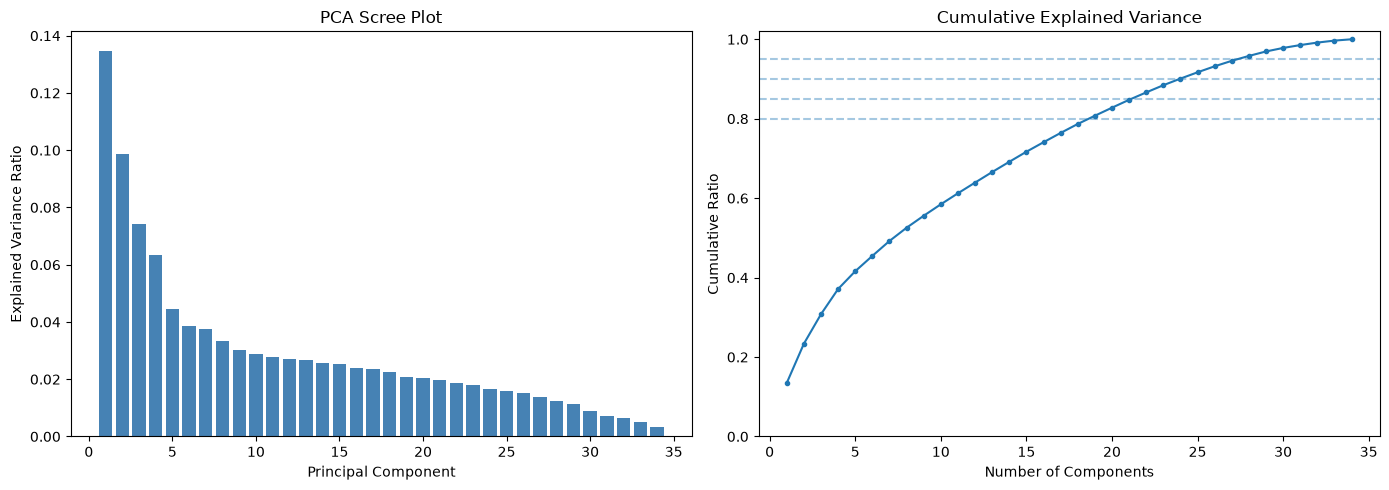

In [10]:
# 차원 축소 효과 확인
components = np.arange(1, len(vif_cols) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(components, pca.explained_variance_ratio_, color='steelblue')
axes[0].set(title='PCA Scree Plot', xlabel='Principal Component', ylabel='Explained Variance Ratio')
axes[1].plot(components, cumulative_variance, marker='o', markersize=3)
for threshold in thresholds:
    axes[1].axhline(threshold, linestyle='--', alpha=0.4)
axes[1].set(title='Cumulative Explained Variance', xlabel='Number of Components', ylabel='Cumulative Ratio', ylim=(0, 1.02))
plt.tight_layout()
plt.show()

## 3. PCA 검토 결과 해석

- 누적 설명분산 80%에는 19개, 85%에는 22개, 90%에는 24개, 95%에는 28개 주성분이 필요합니다. 90%는 수학적으로 정해진 최적값이 아니라 비교용 기준입니다.
- 90% 기준에서 34개가 24개로 줄어 압축 효과가 크지 않습니다. 현재 34개 변수는 VIF 검토를 통과했고 모델링에 과도한 수가 아니므로 PCA를 필수 전처리로 적용할 필요는 낮습니다.
- 각 주성분은 특정 원본 컬럼을 삭제한 결과가 아니라 원본 34개 변수 전체의 가중합입니다. PCA를 적용하면 관리비 항목별 영향 해석이 어려워집니다.
- K-means에서는 PCA가 거리 계산의 중복·노이즈를 줄일 수 있지만 필수는 아닙니다. **표준화한 원본 변수 K-means와 PCA K-means를 동일한 조건에서 비교**하고 군집 품질과 안정성이 실제로 개선될 때만 PCA를 채택합니다.
- 단지 유형을 군집화하려면 월별 133,380행을 그대로 사용하지 않고, 먼저 2,223개 단지(아파트만) 단위의 평균·변동성·추세 특성으로 집계해야 합니다.

# 4. 1단계 구조 군집 변수 준비

향후 K-Means로 "조건이 비슷한 단지"를 묶으려면 규모·연식·시설 관련 변수가 필요하다. `세대수`는 단지가 몇 세대인지는 알려주지만 "세대 하나가 얼마나 큰가"는 담지 못한다. 이를 보완하기 위해 `평균전용면적`(= 주거전용면적(단지합계) ÷ 세대수) 파생변수를 단지 단위로 계산한다.

In [11]:
# 세대수·주거전용면적(단지합계)은 단지별 고정값이므로 단지 단위로 축약한 뒤 계산 (아파트만 필터링된 상태)
complex_df = per_df[['단지코드', '세대수', '주거전용면적(단지합계)']].drop_duplicates('단지코드').reset_index(drop=True)
complex_df['평균전용면적'] = complex_df['주거전용면적(단지합계)'] / complex_df['세대수']

print(f"단지 단위 데이터 크기: {complex_df.shape}")
complex_df.describe()

단지 단위 데이터 크기: (2223, 4)


,세대수,주거전용면적(단지합계),평균전용면적
count,2223.000000,2223.000000,2223.000000
mean,644.773279,49641.614675,78.298890
std,662.448554,55543.531367,23.653811
min,110.000000,2565.952000,13.795441
25%,252.000000,18790.928500,70.903994
50%,435.000000,33045.610000,79.619512
75%,782.500000,59007.745000,85.675106
max,9510.000000,734780.750000,362.141353


In [12]:
# `평균전용면적`을 per_df(월별, 아파트만)에도 추가 — 원본 소스 컬럼이 이미 row-level로 존재하므로 직접 계산
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

print(f"per_df 크기: {per_df.shape}")
per_df[['단지코드', '세대수', '주거전용면적(단지합계)', '평균전용면적']].head()

per_df 크기: (133380, 54)


,단지코드,세대수,주거전용면적(단지합계),평균전용면적
0,A11005401,744.0,94981.45,127.663239
1,A11005401,744.0,94981.45,127.663239
2,A11005401,744.0,94981.45,127.663239
3,A11005401,744.0,94981.45,127.663239
4,A11005401,744.0,94981.45,127.663239


## 4-1. 7개 변수 분포 확인 (왜도, 극단값)

1단계 구조 군집 후보 7개 변수(`세대수`, `평균전용면적`, `사용연수`, `최고층수`, `지하층수`, `승강기대수_perm2`, `총주차대수_perm2`)를 단지 단위로 정리하고, 각 변수의 왜도(skewness)와 IQR 기준 극단값 개수를 확인합니다. (1-1절의 세대수 보정과 비아파트 단지 제외가 모두 반영된 상태입니다.)

In [13]:
STEP1_COLS = ['세대수', '평균전용면적', '사용연수', '최고층수', '지하층수', '승강기대수_perm2', '총주차대수_perm2']
unit_df = per_df.groupby('단지코드')[STEP1_COLS].mean()

def count_iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

dist_summary = pd.DataFrame({
    '평균': unit_df.mean(),
    '표준편차': unit_df.std(),
    '왜도': unit_df.skew(),
    '최솟값': unit_df.min(),
    '최댓값': unit_df.max(),
})
dist_summary['IQR기준_극단값_개수'] = [count_iqr_outliers(unit_df[c]) for c in STEP1_COLS]

print(f"단지 단위 데이터 크기: {unit_df.shape}")
dist_summary

단지 단위 데이터 크기: (2223, 7)


,평균,표준편차,왜도,최솟값,최댓값,IQR기준_극단값_개수
세대수,644.773279,662.448554,3.862006,110.000000,9510.000000,165
평균전용면적,78.298890,23.653811,1.225614,13.795441,362.141353,399
사용연수,22.136484,9.544573,0.035550,1.174949,52.237828,17
최고층수,18.341430,5.477630,1.290845,4.000000,58.000000,76
지하층수,1.590643,1.247768,2.033733,0.000000,21.000000,102
승강기대수_perm2,0.000290,0.000141,4.194749,0.000000,0.002623,106
총주차대수_perm2,0.010168,0.003046,0.961399,0.002889,0.039218,29


# 5. 이상치 처리

**원칙**: 데이터 오류로 확인된 값만 수정/제외하고, 실제 극단 단지는 유지한다(임의로 잘라내면 대형·노후 단지처럼 실제로 존재하는 특성이 왜곡된다). 심한 왜도는 변환을 검토한다.

## 5-1. 데이터 오류 확인

4-1절에서 확인한 7개 변수 각각에 대해 극단값을 실제로 들여다보고 오류 여부를 판단한다.

| 변수 | 확인한 내용 | 판단 |
|---|---|---|
| 세대수 | 1-1절에서 이미 전수 검증(83개 불일치 → 79개 외부 참조자료로 보정) 완료. 보정 후 남은 상위값(헬리오시티 9,510세대, 잠실파크리오 6,864세대, 잠실엘스 5,678세대 등)을 아래 코드로 재확인 | 전부 실존하는 초대형 단지 — **오류 아님, 유지** |
| 평균전용면적 | 세대수 보정 반영 후 상위값(거여현대3차 362㎡, 나인원한남 229㎡, 한남더힐 188㎡ 등)을 아래 코드로 확인 | 전부 실존하는 대형 평형·고급 단지 — **오류 아님, 유지** |
| 사용연수 | 왜도 0.04로 거의 대칭, 극단값 비율도 낮음(17개) | 별도 처리 불필요 |
| 최고층수 | 상위값(자양더샵스타시티 58층, 래미안첼리투스 56층) 확인 | 실존하는 초고층 아파트 — **오류 아님, 유지** (타워팰리스·목동현대하이페리온 등 66~69층 단지는 `단지분류`가 `주상복합`이라 이번 아파트 전용 필터링에서 이미 제외됨) |
| 지하층수 | 최댓값 21(단지코드 A13986701, 중계성원2차, 지상 18층·167세대)이 다음 관측값(9)과 크게 동떨어짐 | 지상 18층 소규모 단지가 지하 21층을 가지는 것은 물리적으로 비현실적 — **데이터 입력 오류로 판단**, 다음으로 높은 관측값(9)으로 대체(정확한 원본 값을 확인할 방법이 없어 보수적으로 대체) |
| 승강기대수_perm2 | 상위값(왕십리 KCC스위첸 등)을 아래 코드로 확인 | 승강기 대수 자체는 정상 범위(7~62대)이고 관리비부과면적이 작아 밀도가 높게 나온 것 — **오류 아님, 유지**. 0인 단지 13개도 저층 소규모 단지라 승강기 미설치가 자연스러움 |
| 총주차대수_perm2 | 상위값(임대단지 다수)·하위값(압구정 현대, 대치쌍용 등 노후 대단지)을 아래 코드로 확인 | 임대단지의 주차 배정 기준 차이, 노후 대단지의 실제 주차난을 반영한 값 — **오류 아님, 유지** |

In [14]:
# 위 표의 판단 근거: 극단값 상위 단지들이 실제로 존재하는 단지인지 이름으로 확인
info_cols = ['단지코드', '단지명', '세대수', '평균전용면적', '최고층수', '승강기대수_perm2', '총주차대수_perm2']
info = per_df[info_cols].drop_duplicates('단지코드')

print("[세대수 상위 5]")
print(info.sort_values('세대수', ascending=False).head(5)[['단지명', '세대수']].to_string(index=False))

print("\n[평균전용면적 상위 5]")
print(info.sort_values('평균전용면적', ascending=False).head(5)[['단지명', '세대수', '평균전용면적']].to_string(index=False))

print("\n[최고층수 상위 5]")
print(info.sort_values('최고층수', ascending=False).head(5)[['단지명', '최고층수']].to_string(index=False))

print("\n[승강기대수_perm2 상위 5]")
print(info.sort_values('승강기대수_perm2', ascending=False).head(5)[['단지명', '승강기대수_perm2']].to_string(index=False))

print("\n[총주차대수_perm2 상위 5 / 하위 5]")
print(info.sort_values('총주차대수_perm2', ascending=False).head(5)[['단지명', '총주차대수_perm2']].to_string(index=False))
print(info.sort_values('총주차대수_perm2').head(5)[['단지명', '총주차대수_perm2']].to_string(index=False))

[세대수 상위 5]
        단지명    세대수
   헬리오시티아파트 9510.0
     잠실파크리오 6864.0
    잠실엘스아파트 5678.0
      잠실리센츠 5563.0
올림픽선수기자촌아파트 5540.0

[평균전용면적 상위 5]
      단지명   세대수     평균전용면적
   거여현대3차 303.0 362.141353
   나인원 한남 341.0 228.950100
방배3차e편한세상 192.0 211.602188
     청암자이 170.0 201.715176
   워커힐아파트 576.0 189.760920

[최고층수 상위 5]
     단지명  최고층수
자양더샵스타시티    58
 래미안첼리투스    56
신도림디큐브시티    51
 아카데미스위트    51
 목동트라팰리스    49

[승강기대수_perm2 상위 5]
             단지명  승강기대수_perm2
서울 왕십리 KCC스위첸아파트     0.002623
   서울수목원현대홈타운스위트     0.001797
        면목경남아너스빌     0.001286
       개포4차현대아파트     0.001218
        도봉숲 아뜨리움     0.001190

[총주차대수_perm2 상위 5 / 하위 5]
             단지명  총주차대수_perm2
서울 왕십리 KCC스위첸아파트     0.039218
          아스하임4차     0.033054
      백련산힐스테이트임대     0.030249
         래미안용두1차     0.025634
      길음뉴타운4단지임대     0.024515
              단지명  총주차대수_perm2
               삼호     0.002889
             안암대광     0.003259
             천호금호     0.003649
           광장극동1차     0.003722
압구정 현대(10,13,14차)     0.003927


In [15]:
# 지하층수 데이터 오류 수정: A13986701(중계성원2차) 21 -> 9 (다음으로 높은 관측값)
per_df.loc[per_df['단지코드'] == 'A13986701', '지하층수'] = 9

unit_df = per_df.groupby('단지코드')[STEP1_COLS].mean()
print("지하층수 최댓값(수정 후):", unit_df['지하층수'].max())

지하층수 최댓값(수정 후): 9.0


## 5-2. 변환 (심한 왜도 보정)

`사용연수`(왜도 0.11, 거의 대칭)를 제외한 6개 변수는 왜도가 1을 넘어 치우쳐 있다. 아래 변환은 0과 음수를 포함해도 적용 가능하고(로그 변환과 달리 0 이하 값에서도 동작), 변환과 동시에 평균 0·표준편차 1로 표준화까지 해준다.

In [16]:
from sklearn.preprocessing import PowerTransformer

TRANSFORM_COLS = ['세대수', '평균전용면적', '최고층수', '지하층수', '승강기대수_perm2', '총주차대수_perm2']

before_skew = unit_df.skew()
before_outliers = {c: count_iqr_outliers(unit_df[c]) for c in STEP1_COLS}

pt = PowerTransformer()
unit_df_transformed = unit_df.copy()
unit_df_transformed[TRANSFORM_COLS] = pt.fit_transform(unit_df[TRANSFORM_COLS])

after_skew = unit_df_transformed.skew()
after_outliers = {c: count_iqr_outliers(unit_df_transformed[c]) for c in STEP1_COLS}

comparison = pd.DataFrame({
    '왜도_변환전': before_skew,
    '왜도_변환후': after_skew,
    'IQR극단값_변환전': pd.Series(before_outliers),
    'IQR극단값_변환후': pd.Series(after_outliers),
})
comparison

,왜도_변환전,왜도_변환후,IQR극단값_변환전,IQR극단값_변환후
세대수,3.862006,0.074862,165,0
평균전용면적,1.225614,0.224655,399,417
사용연수,0.035550,0.035550,17,17
최고층수,1.290845,0.027399,76,67
지하층수,0.514517,-0.070042,102,102
승강기대수_perm2,4.194749,-0.072265,106,32
총주차대수_perm2,0.961399,-0.052748,29,20


**결과 해석**
- 지하층수 오류(21→9) 수정 후 6개 변수에 변환을 적용하자 왜도가 전부 거의 0에 가깝게(좌우 대칭에 가깝게) 개선됐다(예: 세대수 3.86→0.07, 승강기대수_perm2 4.19→-0.07, 최고층수 1.29→0.03).
- IQR 기준 극단값 개수도 대부분 크게 줄었다(세대수 165→0, 승강기대수_perm2 106→32, 최고층수 76→67). `평균전용면적`·`지하층수`는 개선 폭이 작거나 오히려 비슷한데, 이는 단봉이 아닌 분포 형태 때문으로 보인다.
- `unit_df_transformed`는 `사용연수`를 제외한 6개 변수가 이미 표준화(평균 0·표준편차 1)까지 완료된 상태다. `사용연수`는 별도로 `StandardScaler`를 적용해 합치면 1단계 K-Means 입력(오늘 목표 6번)이 된다.

# 6. `StandardScaler` 표준화

5-2절에서 `unit_df_transformed`는 `사용연수`를 제외한 6개 변수가 이미 `PowerTransformer`로 표준화(평균 0·표준편차 1)까지 완료된 상태다. `사용연수`만 별도로 `StandardScaler`를 적용해 합치면 7개 변수 모두 동일한 척도(평균 0·표준편차 1)가 되어 K-Means 거리 계산에 그대로 쓸 수 있다.

In [17]:
X_step1 = unit_df_transformed.copy()
X_step1['사용연수'] = StandardScaler().fit_transform(unit_df[['사용연수']])
X_step1 = X_step1[STEP1_COLS]

print(f"K-Means 입력 크기: {X_step1.shape}")
X_step1.agg(['mean', 'std']).T

K-Means 입력 크기: (2223, 7)


,mean,std
세대수,-2.029665e-15,1.000225
평균전용면적,4.666632e-16,1.000225
사용연수,-1.789941e-16,1.000225
최고층수,-2.045647e-16,1.000225
지하층수,8.949706e-17,1.000225
승강기대수_perm2,4.922338e-16,1.000225
총주차대수_perm2,6.776206e-16,1.000225


# 7. K-Means 실행

`k=2~10`, `n_init=50`(같은 k에서 초기 중심점을 50번 다르게 시도해 그중 가장 좋은 결과 채택), `random_state` 고정으로 재현 가능하게 실행한다.

In [18]:
from sklearn.cluster import KMeans

RANDOM_STATE = 42
K_RANGE = range(2, 11)

kmeans_results = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_step1)
    kmeans_results[k] = {'model': km, 'labels': labels}

print(f"k={K_RANGE.start}~{K_RANGE.stop - 1} K-Means 실행 완료 (n_init=50, random_state={RANDOM_STATE})")

k=2~10 K-Means 실행 완료 (n_init=50, random_state=42)


# 8. 평가지표 계산

k별로 Inertia(군집 내 거리제곱합, Elbow 기법에 사용), Silhouette(높을수록 좋음, -1~1), Davies-Bouldin(낮을수록 좋음), Calinski-Harabasz(높을수록 좋음)를 계산하고, 군집 크기 분포(최소/최대)도 함께 확인해 특정 k에서 극단적으로 작은 군집이 생기지 않는지 본다.

In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

eval_rows = []
for k, res in kmeans_results.items():
    labels = res['labels']
    sizes = pd.Series(labels).value_counts().sort_index()
    eval_rows.append({
        'k': k,
        'Inertia': res['model'].inertia_,
        'Silhouette': silhouette_score(X_step1, labels),
        'Davies-Bouldin': davies_bouldin_score(X_step1, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_step1, labels),
        '최소군집크기': int(sizes.min()),
        '최대군집크기': int(sizes.max()),
    })

eval_df = pd.DataFrame(eval_rows).set_index('k')
eval_df

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,최소군집크기,최대군집크기
k,,,,,,
2,11713.142315,0.251352,1.563717,729.615648,771,1452
3,10023.887785,0.200361,1.642638,613.154765,679,857
4,9111.667251,0.176121,1.637893,523.543752,478,617
5,8315.829963,0.175980,1.627152,483.108337,256,569
6,7869.048002,0.169768,1.641558,433.421110,251,535
7,7471.927190,0.165436,1.670010,399.838509,178,463
8,7090.282425,0.172332,1.642659,378.035303,96,443
9,6760.090950,0.179944,1.522029,360.303333,89,475
10,6451.316019,0.185074,1.517440,347.211339,65,415


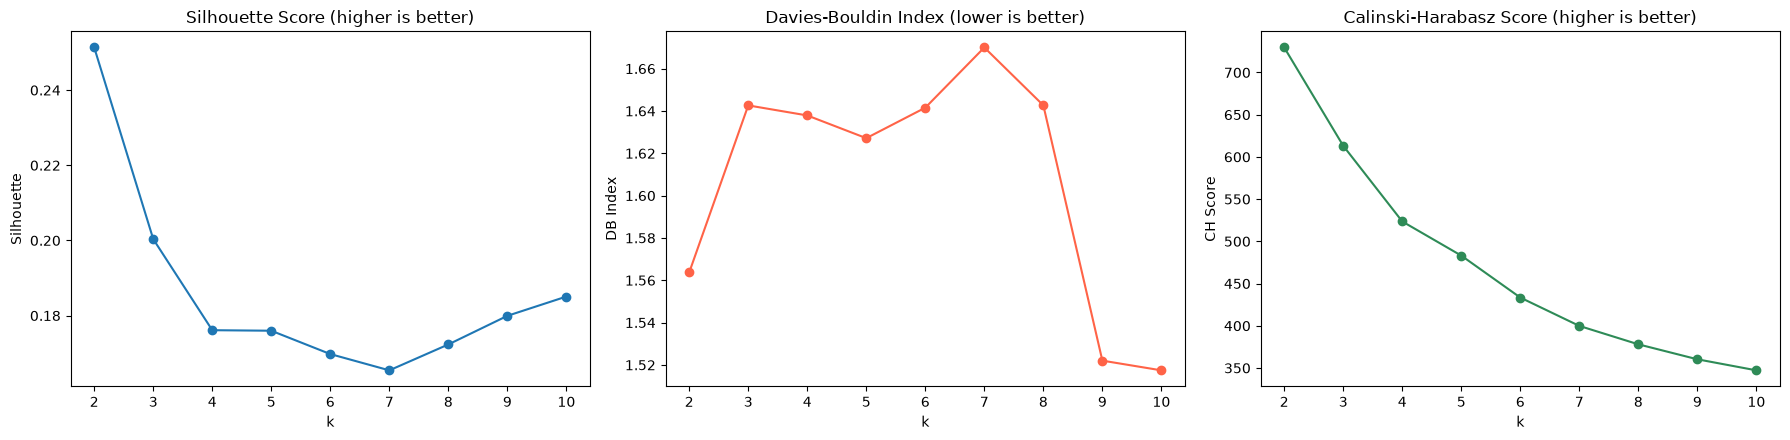

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(eval_df.index, eval_df['Silhouette'], marker='o')
axes[0].set(title='Silhouette Score (higher is better)', xlabel='k', ylabel='Silhouette')
axes[1].plot(eval_df.index, eval_df['Davies-Bouldin'], marker='o', color='tomato')
axes[1].set(title='Davies-Bouldin Index (lower is better)', xlabel='k', ylabel='DB Index')
axes[2].plot(eval_df.index, eval_df['Calinski-Harabasz'], marker='o', color='seagreen')
axes[2].set(title='Calinski-Harabasz Score (higher is better)', xlabel='k', ylabel='CH Score')
plt.tight_layout()
plt.show()

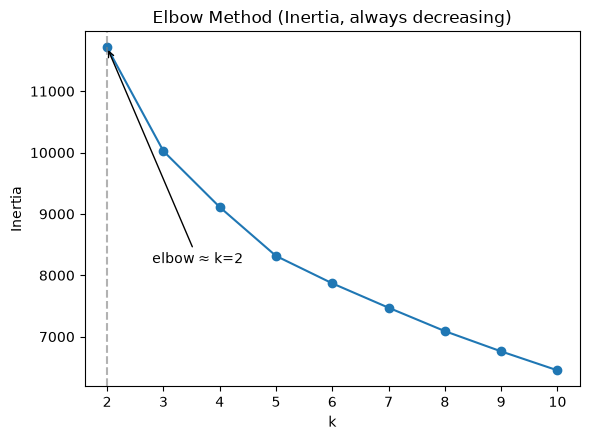

Kneedle 근사 elbow 지점: k=2


In [21]:
# Elbow 기법: k에 따른 관성(Inertia, 군집 내 거리제곱합)의 감소 추이를 보고 꺾이는 지점(elbow)을 찾는다.
# "kneedle" 방식으로 첫 점과 끝 점을 잇는 직선에서 가장 멀리 떨어진 점을 elbow로 근사한다.
ks = eval_df.index.to_numpy(dtype=float)
inertias = eval_df['Inertia'].to_numpy()

x_norm = (ks - ks.min()) / (ks.max() - ks.min())
y_norm = (inertias - inertias.min()) / (inertias.max() - inertias.min())
distances = y_norm - (1 - x_norm)  # 대각선(우하향) 대비 얼마나 위에 있는지
elbow_k = int(eval_df.index[np.argmax(distances)])

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(eval_df.index, inertias, marker='o')
ax.axvline(elbow_k, linestyle='--', color='gray', alpha=0.6)
ax.annotate(f'elbow ≈ k={elbow_k}', xy=(elbow_k, inertias[eval_df.index.get_loc(elbow_k)]),
            xytext=(elbow_k + 0.8, inertias[0] * 0.7), arrowprops=dict(arrowstyle='->'))
ax.set(title='Elbow Method (Inertia, always decreasing)', xlabel='k', ylabel='Inertia')
plt.tight_layout()
plt.show()

print(f"Kneedle 근사 elbow 지점: k={elbow_k}")

# 9. 초기값 안정성 확인

`n_init=50`은 한 번의 `fit` 안에서 초기 중심점만 50번 바꿔보는 것이라, 여기서는 이와 별개로 `random_state`(시드) 자체를 5개 바꿔가며 k별로 K-Means를 반복 실행하고, 시드쌍마다 군집 결과가 얼마나 일치하는지 **Adjusted Rand Index(ARI)**로 측정한다. ARI는 1에 가까울수록 두 실행의 군집 결과가 (라벨 번호가 달라도) 사실상 같다는 뜻이다.

In [22]:
from sklearn.metrics import adjusted_rand_score

STABILITY_SEEDS = [0, 1, 2, 3, 4]

def stability_ari(X, k, seeds=STABILITY_SEEDS, n_init=50):
    labels_list = [KMeans(n_clusters=k, n_init=n_init, random_state=s).fit_predict(X) for s in seeds]
    aris = [adjusted_rand_score(labels_list[i], labels_list[j])
            for i in range(len(labels_list)) for j in range(i + 1, len(labels_list))]
    return np.mean(aris), np.min(aris)

stability_rows = []
for k in K_RANGE:
    mean_ari, min_ari = stability_ari(X_step1, k)
    stability_rows.append({'k': k, 'ARI_평균': mean_ari, 'ARI_최소': min_ari})

stability_df = pd.DataFrame(stability_rows).set_index('k')

summary_df = eval_df.join(stability_df)
summary_df

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,최소군집크기,최대군집크기,ARI_평균,ARI_최소
k,,,,,,,,
2,11713.142315,0.251352,1.563717,729.615648,771,1452,1.000000,1.000000
3,10023.887785,0.200361,1.642638,613.154765,679,857,0.997767,0.995817
4,9111.667251,0.176121,1.637893,523.543752,478,617,0.996919,0.994431
5,8315.829963,0.175980,1.627152,483.108337,256,569,0.996688,0.994194
6,7869.048002,0.169768,1.641558,433.421110,251,535,0.968328,0.943512
7,7471.927190,0.165436,1.670010,399.838509,178,463,0.979121,0.954243
8,7090.282425,0.172332,1.642659,378.035303,96,443,0.977687,0.964661
9,6760.090950,0.179944,1.522029,360.303333,89,475,0.820143,0.630668
10,6451.316019,0.185074,1.517440,347.211339,65,415,0.733628,0.621896


# 10. 결과 정리

## 10-1. 최적 k 후보 선정 근거

`summary_df`(8·9절 결과)를 종합하면:
- **Elbow(Inertia)**: Kneedle 근사로 찾은 elbow는 k=2다. Inertia는 k가 커질수록 항상 감소하는 지표라 뚜렷한 "꺾임"이 크지 않고, 감소폭이 완만하게 줄어드는 형태라 elbow가 가장 이른 지점(k=2)에서 잡혔다.
- **Silhouette**은 k=2(0.251)에서 가장 높고 k=7(0.165)까지 단조 감소하다가 k=8~10에서 소폭 반등한다.
- **Calinski-Harabasz**는 k=2(729.6)부터 k=10(347.2)까지 계속 감소하는데, 감소폭이 k=4→5 구간(Δ90→Δ40)에서 절반 이하로 꺾여 이 지점을 elbow로 볼 수 있다.
- **Davies-Bouldin**은 k=9~10에서 가장 낮지만(1.52 부근) k=2~5와 큰 차이가 없다.
- **초기값 안정성(ARI)**이 결정적이다 — k=2~5는 서로 다른 시드로 5번 반복해도 ARI 평균 0.997~1.000(사실상 동일한 군집)로 매우 안정적이지만, k=9~10은 ARI 평균 0.73~0.82·최소 0.62~0.63까지 떨어져 시드에 따라 군집 결과가 크게 달라진다 — 즉 8~10에서의 Silhouette 반등은 실제 구조가 아니라 노이즈에 의한 우연한 분할일 가능성이 높다.
- 군집 크기도 k=2~5까지는 최소 군집이 256개 이상으로 고르게 나뉘지만, k=8 이상부터는 최소 군집이 65~96개로 급격히 작아진다.

**결론**: Elbow·Silhouette·Calinski-Harabasz 모두 통계적으로는 k=2가 가장 뚜렷한 분리를 보이지만, "유사 단지끼리 묶어 비교"하려는 목적에는 이분류(대형/소형 수준)가 지나치게 거칠다. 반면 k=6 이상은 안정성이 떨어지기 시작한다. k=2~5 구간은 어차피 ARI가 거의 1에 가까워 어느 k를 골라도 안정적이므로, 그 안에서 실질적인 세분화가 시작되는 지점(Calinski-Harabasz 감소폭이 꺾이는 k=4→5)을 기준으로 **k=4를 1차 후보**로 채택하고, 더 세분화하고 싶다면 안정성이 아직 높은 **k=5**를 대안으로 남긴다. k≥9는 불안정하여 후보에서 제외한다.

## 10-2. 군집별 변수 평균 프로파일 (k=4)

In [23]:
BEST_K = 4
best_labels = kmeans_results[BEST_K]['labels']

cluster_profile = unit_df.copy()
cluster_profile['cluster'] = best_labels

profile_table = cluster_profile.groupby('cluster')[STEP1_COLS].mean()
profile_table['단지수'] = cluster_profile.groupby('cluster').size()
profile_table['비중(%)'] = (profile_table['단지수'] / len(cluster_profile) * 100).round(1)
profile_table

,세대수,평균전용면적,사용연수,최고층수,지하층수,승강기대수_perm2,총주차대수_perm2,단지수,비중(%)
cluster,,,,,,,,,
0,1073.319149,82.695830,14.947114,24.659574,2.495164,0.000257,0.011826,517,23.3
1,377.171548,74.796960,15.326751,14.949791,1.738494,0.000449,0.012437,478,21.5
2,846.631751,74.783513,32.744550,14.782324,0.399345,0.000237,0.007102,611,27.5
3,293.103728,80.808777,22.931345,19.199352,1.878444,0.000247,0.010056,617,27.8


## 10-3. 프로파일 해석 (k=4)

| 군집 | 단지수(비중) | 세대수 | 평균전용면적 | 사용연수 | 최고층수 | 지하층수 | 특징 요약 |
|---|---|---|---|---|---|---|---|
| 0 | 517개(23.3%) | 1,073 | 82.7㎡ | 14.9년 | 24.7층 | 2.50 | **대형·고층 신축형** — 세대수·최고층수·지하층수 모두 가장 높고 연식은 가장 젊은 축. 최근 지어진 대단지 고층 아파트. |
| 1 | 478개(21.5%) | 377 | 74.8㎡ | 15.3년 | 14.9층 | 1.74 | **중형 저층 신축형** — 연식은 0번과 비슷하게 젊지만 규모·층수는 절반 이하. 승강기·주차 밀도(면적당)는 4개 군집 중 가장 높음(면적 자체가 작아 상대적으로 밀도가 높게 나옴). |
| 2 | 611개(27.5%) | 847 | 74.8㎡ | 32.7년 | 14.8층 | 0.40 | **대형 노후형** — 사용연수가 압도적으로 높고(32.7년) 지하층수는 거의 0에 가까움(옛날 단지라 지하주차장이 없거나 얕음), 주차 밀도도 가장 낮음(주차난 경향). 규모는 크지만 연식이 오래된 단지. |
| 3 | 617개(27.8%) | 293 | 80.8㎡ | 22.9년 | 19.2층 | 1.88 | **소형 중년형** — 세대수가 가장 적고 연식·층수는 중간 수준. 4개 군집 중 가장 "평균적"인 그룹. |

**해석 요약**
- k=4는 사실상 **연식(신축/노후)**과 **규모(대형/중소형)**라는 두 축의 조합으로 갈린다: 대형·신축(0), 중형·신축(1), 대형·노후(2), 소형·중년(3).
- 특히 군집 2(대형 노후형)는 지하층수가 0.40으로 나머지 군집(1.74~2.50)과 뚜렷이 구분되는데, 이는 지하주차장이 보편화되기 전에 지어진 노후 대단지라는 실제 특성과 일치해 군집이 물리적으로 의미 있는 그룹을 포착했음을 시사한다.
- 다음 단계(2단계 비용 벤치마킹)에서는 이 4개 군집 각각의 내부에서 면적당 관리비 수준을 비교하게 된다.

## 10-4. 군집 시각화 (k=2, 4, 5 비교)

`X_step1`은 7차원이라 그대로 그릴 수 없으므로, 시각화 전용으로 PCA 2개 성분에 투영해 2D 산점도를 그린다(이 PCA는 3절의 34개 변수 PCA 검토와는 별개로, 7개 변수짜리 `X_step1`에 대해 시각화 목적으로만 새로 적용한 것이다). 아울러 가장 해석하기 쉬운 두 원본 변수(세대수·사용연수)로도 같은 군집을 그려 비교한다.

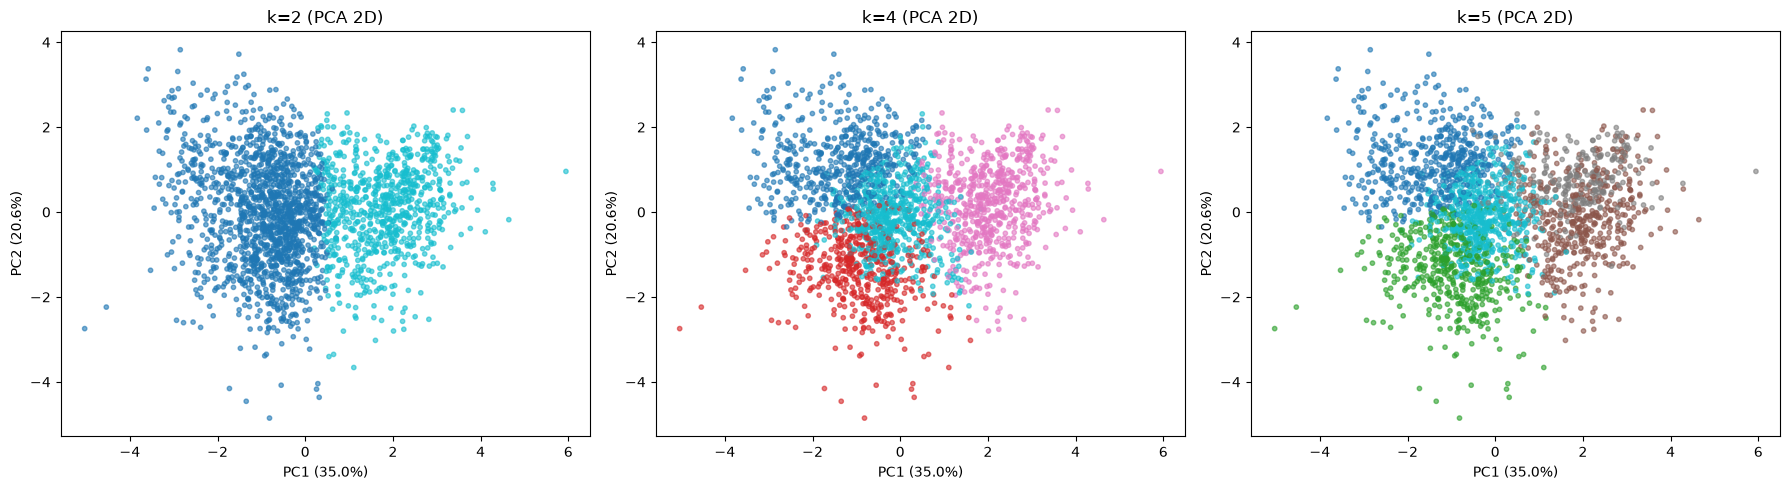

시각화용 PCA 2개 성분 누적 설명분산: 55.6%


In [24]:
VIS_KS = [2, 4, 5]

# (1) PCA 2성분 투영 산점도 - 시각화 전용 (X_step1의 7개 변수 기준)
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_vis.fit_transform(X_step1)
explained = pca_vis.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, VIS_KS):
    labels = kmeans_results[k]['labels']
    ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=10, alpha=0.6)
    ax.set(title=f'k={k} (PCA 2D)', xlabel=f'PC1 ({explained[0]:.1%})', ylabel=f'PC2 ({explained[1]:.1%})')
plt.tight_layout()
plt.show()

print(f"시각화용 PCA 2개 성분 누적 설명분산: {explained.sum():.1%}")

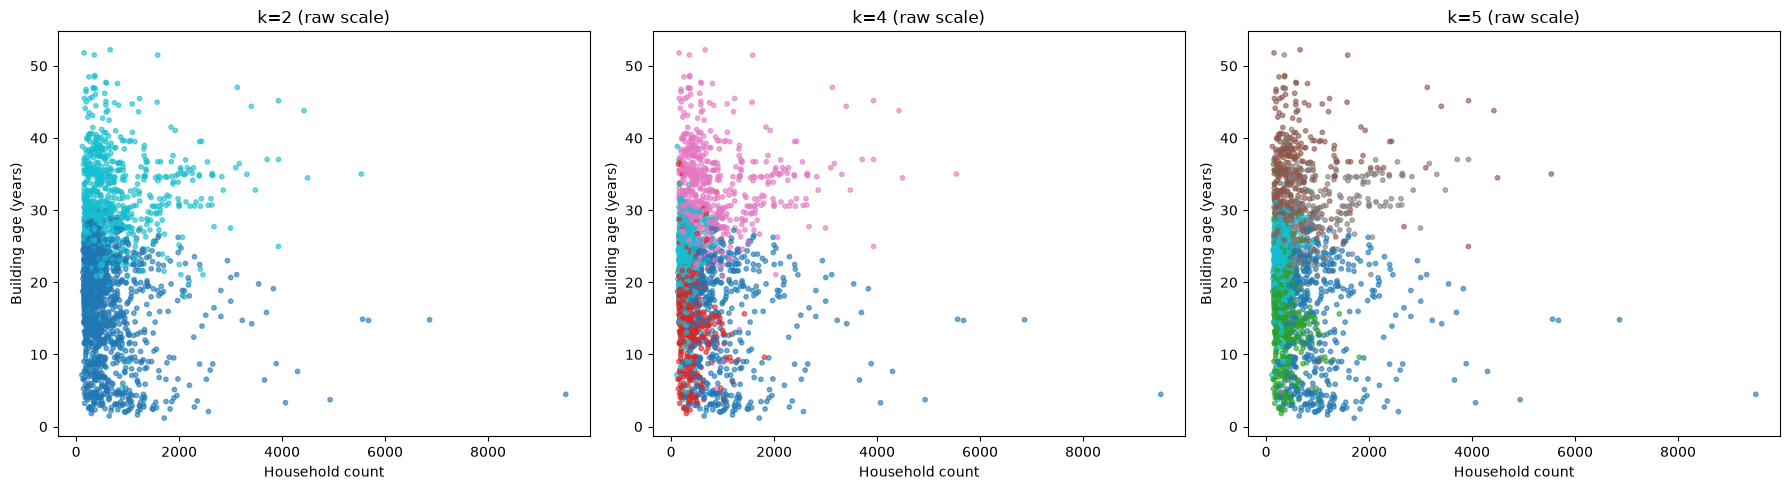

In [25]:
# (2) 해석하기 쉬운 원본 변수(세대수 vs 사용연수)로도 같은 군집 확인
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, VIS_KS):
    labels = kmeans_results[k]['labels']
    ax.scatter(unit_df['세대수'], unit_df['사용연수'], c=labels, cmap='tab10', s=10, alpha=0.6)
    ax.set(title=f'k={k} (raw scale)', xlabel='Household count', ylabel='Building age (years)')
plt.tight_layout()
plt.show()